#### Neighbor contribution to a task's AI-execution likelihood — Weekly/Daily frequency cuts
#### By: Peyman Shahidi (robustness build)
#### Created: 2026-06-25

**Headline being tested.** In the task-sequence logit, the probability that a *focal* task is executed by AI
rises when its **neighboring tasks** (positions t-2, t-1, t+1, t+2) are themselves AI tasks. We re-estimate this
on workflows pruned to **frequently-executed tasks only**, and sweep how the headline moves as we slice the
sequences differently.

**Frequency cuts.** ONET's *Frequency of Task* (`FT`) scale has seven categories. We use two families:
*weekly-or-more* = categories 4-7 (More than weekly, Daily, Several times daily, Hourly or more) and
*daily-or-more* = categories 5-7. A task is kept when the combined incumbent share in the family's categories
is at least a threshold. Daily+ is the stricter cut (shorter sequences); weekly+ is more inclusive.

**Method.** We prune the existing workflows (no LLM re-query), preserve the order of the surviving tasks,
recompute neighbor flags, and re-run the logit. **No reshuffle / null distribution** is run here (per request) —
only the main observed specifications. Inference uses **analytic DWA-clustered robust standard errors** on the
logit coefficients (instant); the average marginal effects (AMEs) reported are the discrete-change effects
(identical to the paper's point estimates), and significance stars come from the clustered coefficient test.

In [1]:
import os, glob
import numpy as np, pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 200); pd.set_option('display.width', 200)

In [2]:
# ====================== PARAMETERS ======================
dependent_var = 'is_ai'                    # focal task executed by AI (Augmentation|Automation)
TARGET_REGS  = ['prev2_is_ai', 'prev_is_ai', 'next_is_ai', 'next2_is_ai']
VAR_LABELS = {'prev2_is_ai': '(t-2) AI', 'prev_is_ai': '(t-1) AI', 'next_is_ai': '(t+1) AI', 'next2_is_ai': '(t+2) AI'}

# Frequency filtering logics = cumulative ONET FT tails (inclusive -> restrictive)
FT_MONTHLY      = ['FT_More than monthly', 'FT_More than weekly', 'FT_Daily', 'FT_Several times daily', 'FT_Hourly or more']  # FT 3-7
FT_WEEKLY       = ['FT_More than weekly', 'FT_Daily', 'FT_Several times daily', 'FT_Hourly or more']                          # FT 4-7
FT_DAILY        = ['FT_Daily', 'FT_Several times daily', 'FT_Hourly or more']                                                 # FT 5-7
FT_SEVERALDAILY = ['FT_Several times daily', 'FT_Hourly or more']                                                             # FT 6-7
FT_HOURLY       = ['FT_Hourly or more']                                                                                       # FT 7
ALL_FT_COLS = ['FT_Yearly or less', 'FT_More than yearly', 'FT_More than monthly', 'FT_More than weekly',
               'FT_Daily', 'FT_Several times daily', 'FT_Hourly or more']
FAMILIES = [('Daily+', 'daily', FT_DAILY), ('SeveralDaily+', 'sevdaily', FT_SEVERALDAILY),
            ('Hourly+', 'hourly', FT_HOURLY)]
SWEEP_THRESHOLDS = [20, 35, 50, 65]
PRIMARY_FAMILY, PRIMARY_THRESHOLD = FT_WEEKLY, 50.0    # primary "frequent" definition for the main Step-3 table

# full grid of cuts (logic x threshold) + the all-tasks baseline
CUTS = [('All tasks', 'all', None, None)] + [(f"{lab} >={t}%", tag, cols, t) for (lab, tag, cols) in FAMILIES for t in SWEEP_THRESHOLDS]

In [3]:
main_folder_path = ".."
input_data_path = f"{main_folder_path}/data"
merged_file = f"{input_data_path}/computed_objects/ONET_Eloundou_Anthropic_GPT/ONET_Eloundou_Anthropic_GPT.csv"
output_data_path = f"{input_data_path}/computed_objects/execTypeVaryingDWA_anthropicIndex_weeklyTasks"
output_plot_path = f"{main_folder_path}/writeup/plots/execTypeVaryingDWA_weeklyTasks"
for p in [output_data_path, output_plot_path]: os.makedirs(p, exist_ok=True)

## Load the DWA helper objects (identical to the baseline `onet_antrhopicIndex_execTypeVaryingDWA.ipynb`)

In [4]:
# Tasks that survived the DWA task-similarity procedure (DWAs with >1 task)
dwa_csv_files = glob.glob(os.path.join(f"{input_data_path}/computed_objects/similar_dwa_tasks/similarTasks", "*.csv"))
dwa_dfs = [pd.read_csv(f) for f in dwa_csv_files]
df_all = pd.concat([d for d in dwa_dfs if len(d) > 1], ignore_index=True)
repetitive_dwa_task_ids = df_all['Task ID'].unique().tolist()

dwa_task_mapping = pd.read_csv(f"{input_data_path}/computed_objects/similar_dwa_tasks/dwa_task_mapping.csv")
dwa_task_counts = dwa_task_mapping.groupby('Task ID')['DWA ID'].nunique().reset_index(name='n')
unique_task_dwa_mapping = dwa_task_counts[dwa_task_counts['n'] == 1]['Task ID'].tolist()  # keep single-DWA tasks

# DWAs with varying execution type across occupations (for the GPT-filtered dataset)
_md = pd.read_csv(merged_file); _md['is_manual'] = _md['label'] == 'Manual'
_md = _md.merge(dwa_task_mapping, on=['Task ID', 'Task Title', 'O*NET-SOC Code', 'Occupation Title'], how='left')
_dg = _md.groupby(['DWA ID', 'DWA Title']).agg(no=('O*NET-SOC Code', 'nunique'), fm=('is_manual', 'mean')).reset_index()
dwas_varying_exec_types_ids = _dg[(_dg['no'] > 1) & (_dg['fm'] > 0) & (_dg['fm'] < 1)]['DWA ID'].unique().tolist()
print(f"single-DWA tasks: {len(unique_task_dwa_mapping):,} | DWAs with varying exec types: {len(dwas_varying_exec_types_ids):,}")

single-DWA tasks: 13,748 | DWAs with varying exec types: 831


## Build the analytic sample (with frequency pruning) — mirrors the baseline preprocessing

In [5]:
def build_dataset(family_cols, threshold):
    '''Prune the merged workflows to a frequency cut (family_cols/threshold; None=all tasks),
    recompute neighbor flags on the surviving ordered tasks, then apply the baseline DWA filters.
    Returns (full_eligible_df, gpt_filtered_df).'''
    d = pd.read_csv(merged_file)
    d = d[['O*NET-SOC Code', 'Occupation Title', 'Task ID', 'Task Title', 'Task Position',
           'Major_Group_Code', 'Minor_Group_Code', 'gpt4_exposure', 'human_labels', 'label']
          + ALL_FT_COLS].copy()
    d['is_ai'] = d['label'].isin(['Augmentation', 'Automation']).astype(int)
    d['is_automated'] = d['label'].isin(['Automation']).astype(int)
    d['is_exposed'] = d['human_labels'].isin(['E1']).astype(int)
    # ---- frequency prune (preserve order) ----
    if family_cols is not None:
        d = d[d[family_cols].sum(axis=1) >= threshold].reset_index(drop=True)
    # occupation task count (after prune)
    n = d.groupby('O*NET-SOC Code')['Task ID'].nunique().reset_index().rename(columns={'Task ID': 'num_tasks'})
    d = d.merge(n, on='O*NET-SOC Code', how='left')
    # ---- neighbor flags on surviving ordered sequence ----
    d['Task Position'] = pd.to_numeric(d['Task Position'], errors='coerce')
    d = d.sort_values(['O*NET-SOC Code', 'Task Position']).reset_index(drop=True)
    g = d.groupby('O*NET-SOC Code')['is_ai']
    d['prev_is_ai'] = g.shift(1); d['prev2_is_ai'] = g.shift(2); d['next_is_ai'] = g.shift(-1); d['next2_is_ai'] = g.shift(-2)
    nb = ['prev_is_ai', 'prev2_is_ai', 'next_is_ai', 'next2_is_ai']
    d = d.dropna(subset=nb).reset_index(drop=True)
    for c in nb: d[c] = d[c].astype(int)
    # ---- DWA filters (identical to baseline) ----
    d = d.merge(dwa_task_mapping, on=['Task ID', 'Task Title', 'O*NET-SOC Code', 'Occupation Title'], how='left')
    d = d[d['Task ID'].isin(unique_task_dwa_mapping)].reset_index(drop=True)         # single-DWA tasks only
    d = d.drop_duplicates(subset=['O*NET-SOC Code', 'Task ID']).reset_index(drop=True)
    d = d[~d['DWA ID'].isna()].reset_index(drop=True)
    occ = d.groupby('DWA ID')['O*NET-SOC Code'].nunique(); keep = occ[occ > 1].index   # DWAs in >1 occupation
    d = d[d['DWA ID'].isin(keep)].reset_index(drop=True)
    cnt = d.groupby(['DWA ID', 'O*NET-SOC Code'])['Task ID'].nunique().reset_index(name='num_tasks_in_dwa_within_occupation')
    d = d.merge(cnt, on=['DWA ID', 'O*NET-SOC Code'], how='left')
    filt = d[(d['DWA ID'].isin(dwas_varying_exec_types_ids) & d['Task ID'].isin(repetitive_dwa_task_ids))].reset_index(drop=True)
    for x in (d, filt):                       # pandas>=3.0: object dtype so patsy can build design matrices
        sc = x.select_dtypes(include=['string']).columns; x[sc] = x[sc].astype(object)
    return d, filt

## Step 1 — How many workflow tasks are infrequent? (diagnostic)

In [6]:
raw = pd.read_csv(merged_file)
n_all = len(raw)
print(f"Original workflow task-rows: {n_all:,}\n")
print(f"{'cut':<16}{'kept':>10}{'kept %':>9}{'dropped':>10}{'dropped %':>11}")
for label, tag, cols, thr in CUTS:
    if cols is None:
        print(f"{label:<16}{n_all:>10,}{100.0:>8.1f}%{0:>10,}{0.0:>10.1f}%"); continue
    k = int((raw[cols].sum(axis=1) >= thr).sum())
    print(f"{label:<16}{k:>10,}{k/n_all*100:>8.1f}%{n_all-k:>10,}{(n_all-k)/n_all*100:>10.1f}%")

Original workflow task-rows: 17,925

cut                   kept   kept %   dropped  dropped %
All tasks           17,925   100.0%         0       0.0%
Daily+ >=20%        13,220    73.8%     4,705      26.2%
Daily+ >=35%        10,451    58.3%     7,474      41.7%
Daily+ >=50%         8,099    45.2%     9,826      54.8%
Daily+ >=65%         5,834    32.5%    12,091      67.5%
SeveralDaily+ >=20%     7,581    42.3%    10,344      57.7%
SeveralDaily+ >=35%     4,638    25.9%    13,287      74.1%
SeveralDaily+ >=50%     2,654    14.8%    15,271      85.2%
SeveralDaily+ >=65%     1,240     6.9%    16,685      93.1%
Hourly+ >=20%        4,051    22.6%    13,874      77.4%
Hourly+ >=35%        1,902    10.6%    16,023      89.4%
Hourly+ >=50%          870     4.9%    17,055      95.1%
Hourly+ >=65%          311     1.7%    17,614      98.3%


## Step 2 — Observed regression runner (analytic DWA-clustered inference)

In [7]:
def _ame(res, df, target):
    out = {}
    for v in target:
        d1 = df.copy(); d0 = df.copy(); d1[v] = 1; d0[v] = 0
        out[v] = float(np.mean(res.predict(d1) - res.predict(d0)))
    return out

def run_observed(df, target=TARGET_REGS, dep=dependent_var):
    '''Six specifications mirroring the baseline. For each, returns per-term (AME, clustered p-value),
    plus nobs / FE label / DWA-FE flag. Significance stars use the clustered coefficient test
    (for a binary regressor the AME is significant iff the coefficient is).'''
    df = df.copy(); df['DWA_ID'] = df['DWA ID']
    base = f'{dep} ~ ' + ' + '.join(target)
    out = {}
    def fit(formula, data, cluster):
        res = smf.logit(formula, data=data).fit(disp=False, cov_type='cluster',
                                                cov_kwds={'groups': data[cluster], 'use_correction': True})
        ame = _ame(res, data, target)
        return {'nobs': int(res.nobs), 'pr2': float(res.prsquared),
                **{t: (ame[t], float(res.pvalues.get(t, np.nan))) for t in target}}
    specs = [
        ('no_fe_no_dwa', base + ' + is_exposed + num_tasks', df, 'DWA ID', 'None', False),
        ('major_fe_no_dwa', base + ' + C(Major_Group_Code) + is_exposed + num_tasks',
            df.groupby('Major_Group_Code').filter(lambda g: g[dep].nunique() > 1), 'DWA ID', 'Major', False),
        ('minor_fe_no_dwa', base + ' + C(Minor_Group_Code) + is_exposed + num_tasks',
            df.groupby('Minor_Group_Code').filter(lambda g: g[dep].nunique() > 1), 'DWA ID', 'Minor', False),
    ]
    df_dwa = df.groupby('DWA_ID').filter(lambda g: g[dep].nunique() > 1)
    specs += [
        ('no_fe_with_dwa', base + ' + C(DWA_ID) + is_exposed + num_tasks', df_dwa, 'DWA_ID', 'None', True),
        ('no_fe_no_dwa_withTaskDWACount', base + ' + is_exposed + num_tasks + num_tasks_in_dwa_within_occupation', df_dwa, 'DWA_ID', 'None', False),
        ('no_fe_with_dwa_withTaskDWACount', base + ' + C(DWA_ID) + is_exposed + num_tasks + num_tasks_in_dwa_within_occupation', df_dwa, 'DWA_ID', 'None', True),
    ]
    for name, formula, data, cluster, fe, dwafe in specs:
        try:
            r = fit(formula, data, cluster); r['fe'] = fe; r['dwa_fe'] = dwafe; out[name] = r
        except Exception as e:
            print(f"  [{name}] failed: {e}")
    return out

SPEC_ORDER = ['no_fe_no_dwa', 'major_fe_no_dwa', 'minor_fe_no_dwa', 'no_fe_with_dwa',
              'no_fe_no_dwa_withTaskDWACount', 'no_fe_with_dwa_withTaskDWACount']
star = lambda p: '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''

## Step 3 — Main result: baseline (all tasks) vs frequent (weekly+ >=50%)

For the *full-eligible* sample and the *GPT-filtered* sample, across all six specifications. AME = change in
the probability the focal task is AI-executed when the neighbor is an AI task.

In [8]:
ds_full_all, ds_filt_all = build_dataset(None, None)                              # baseline
ds_full_frq, ds_filt_frq = build_dataset(PRIMARY_FAMILY, PRIMARY_THRESHOLD)        # weekly+ >=50%
print("analytic sample sizes (task-rows):")
print(f"  full-eligible : all={len(ds_full_all):,}  weekly+>=50%={len(ds_full_frq):,}")
print(f"  GPT-filtered  : all={len(ds_filt_all):,}  weekly+>=50%={len(ds_filt_frq):,}")

res = {'full_all': run_observed(ds_full_all), 'full_frq': run_observed(ds_full_frq),
       'filt_all': run_observed(ds_filt_all), 'filt_frq': run_observed(ds_filt_frq)}

analytic sample sizes (task-rows):
  full-eligible : all=10,708  weekly+>=50%=5,728
  GPT-filtered  : all=3,689  weekly+>=50%=1,707


In [9]:
def cmp_table(key_all, key_frq, title):
    print(f"\n=== {title} ===")
    print("AME (stars from DWA-clustered coefficient test); 'all' = baseline, 'frq' = weekly+ >=50%\n")
    rows = []
    for term in TARGET_REGS:
        r = {'neighbor': VAR_LABELS[term]}
        for sp in SPEC_ORDER:
            a = res[key_all].get(sp, {}).get(term); f = res[key_frq].get(sp, {}).get(term)
            r[f'{sp}|all'] = f"{a[0]:.3f}{star(a[1])}" if a else "."
            r[f'{sp}|frq'] = f"{f[0]:.3f}{star(f[1])}" if f else "."
        rows.append(r)
    nrow = {'neighbor': 'N (obs)'}
    for sp in SPEC_ORDER:
        a = res[key_all].get(sp, {}); f = res[key_frq].get(sp, {})
        nrow[f'{sp}|all'] = f"{a.get('nobs','.'):,}" if a else "."
        nrow[f'{sp}|frq'] = f"{f.get('nobs','.'):,}" if f else "."
    rows.append(nrow)
    return pd.DataFrame(rows)

# Print compact (immediate neighbors are the headline: t-1, t+1)
def compact(key_all, key_frq, title):
    print(f"\n=== {title} — immediate neighbors (t-1, t+1) ===")
    hdr = f"{'spec':<34}{'(t-1) all':>12}{'(t-1) frq':>12}{'(t+1) all':>12}{'(t+1) frq':>12}{'N all':>9}{'N frq':>9}"
    print(hdr)
    for sp in SPEC_ORDER:
        a = res[key_all].get(sp, {}); f = res[key_frq].get(sp, {})
        def cell(d, t):
            v = d.get(t); return f"{v[0]:.3f}{star(v[1])}" if v else "."
        print(f"{sp:<34}{cell(a,'prev_is_ai'):>12}{cell(f,'prev_is_ai'):>12}"
              f"{cell(a,'next_is_ai'):>12}{cell(f,'next_is_ai'):>12}"
              f"{a.get('nobs',0):>9,}{f.get('nobs',0):>9,}")

compact('full_all', 'full_frq', 'FULL-ELIGIBLE dataset')
compact('filt_all', 'filt_frq', 'GPT-FILTERED dataset')

# Save full comparison tables
cmp_table('full_all', 'full_frq', 'FULL-ELIGIBLE').to_csv(f"{output_data_path}/ame_comparison_full_eligible.csv", index=False)
cmp_table('filt_all', 'filt_frq', 'GPT-FILTERED').to_csv(f"{output_data_path}/ame_comparison_gpt_filtered.csv", index=False)
print("\nSaved AME comparison CSVs to", output_data_path)


=== FULL-ELIGIBLE dataset — immediate neighbors (t-1, t+1) ===
spec                                 (t-1) all   (t-1) frq   (t+1) all   (t+1) frq    N all    N frq
no_fe_no_dwa                          0.124***    0.101***    0.117***    0.094***   10,708    5,728
major_fe_no_dwa                       0.061***    0.041***    0.057***    0.037***   10,708    5,662
minor_fe_no_dwa                       0.051***     0.029**    0.048***     0.027**    9,861    4,983
no_fe_with_dwa                         0.052**       0.022     0.041**       0.014    4,096    1,659
no_fe_no_dwa_withTaskDWACount         0.130***    0.119***    0.100***    0.100***    4,096    1,659
no_fe_with_dwa_withTaskDWACount        0.052**       0.022     0.042**       0.015    4,096    1,659

=== GPT-FILTERED dataset — immediate neighbors (t-1, t+1) ===
spec                                 (t-1) all   (t-1) frq   (t+1) all   (t+1) frq    N all    N frq
no_fe_no_dwa                          0.109***    0.126***    0.1

## Step 4 — Filtering-logic × threshold sweep: how the headline neighbor effect moves

Headline = the AME of the immediate neighbors **(t-1)** and **(t+1)** being AI tasks, for the full-eligible
sample, across five filtering logics (Monthly+/Weekly+/Daily+/SeveralDaily+/Hourly+ — cumulative ONET `FT`
tails) × thresholds 20 / 35 / 50 / 65%. We report the three no-DWA-FE specifications. Cells where a cut leaves
too little data to estimate are blank.

In [10]:
# light runner for the sweep: the three no-DWA-FE specs only (fast, robust on small cuts)
def run_sweep(df, dep=dependent_var, target=TARGET_REGS):
    if len(df) < 60 or df[dep].nunique() < 2:
        return {}
    base = f'{dep} ~ ' + ' + '.join(target)
    out = {}
    specs = [('no_fe_no_dwa', base + ' + is_exposed + num_tasks', df),
             ('major_fe_no_dwa', base + ' + C(Major_Group_Code) + is_exposed + num_tasks',
                 df.groupby('Major_Group_Code').filter(lambda g: g[dep].nunique() > 1)),
             ('minor_fe_no_dwa', base + ' + C(Minor_Group_Code) + is_exposed + num_tasks',
                 df.groupby('Minor_Group_Code').filter(lambda g: g[dep].nunique() > 1))]
    for name, formula, data in specs:
        try:
            r = smf.logit(formula, data=data).fit(disp=False, cov_type='cluster',
                                                  cov_kwds={'groups': data['DWA ID'], 'use_correction': True})
            a = _ame(r, data, target)
            out[name] = {'nobs': int(r.nobs), **{t: (a[t], float(r.pvalues.get(t, np.nan))) for t in target}}
        except Exception:
            pass
    return out

sweep_rows = []
for label, tag, cols, thr in CUTS:
    full_d, _ = build_dataset(cols, thr)
    r = run_sweep(full_d)
    for sp, d in r.items():
        for term in TARGET_REGS:
            v = d.get(term)
            if v:
                sweep_rows.append({'cut': label, 'family': tag, 'threshold': thr if thr is not None else 0,
                                   'spec': sp, 'term': term, 'ame': v[0], 'pval': v[1], 'nobs': d.get('nobs')})
sweep = pd.DataFrame(sweep_rows)
sweep.to_csv(f"{output_data_path}/neighbor_logic_threshold_sweep.csv", index=False)
print("Saved sweep (", len(sweep), "rows ) to neighbor_logic_threshold_sweep.csv")
b = sweep[(sweep.family=='all')&(sweep.spec=='no_fe_no_dwa')]
print("Baseline (all tasks) no-FE AME  (t-1):", round(b[b.term=='prev_is_ai']['ame'].iloc[0],3),
      " (t+1):", round(b[b.term=='next_is_ai']['ame'].iloc[0],3))

Saved sweep ( 144 rows ) to neighbor_logic_threshold_sweep.csv
Baseline (all tasks) no-FE AME  (t-1): 0.124  (t+1): 0.117


In [11]:
# Row 0 = "All tasks" (no pruning) = the most relaxed cut = the spec currently reported in the paper.
fam_order = ['daily', 'sevdaily', 'hourly']
fam_label = {'daily':'Daily+', 'sevdaily':'SeveralDaily+', 'hourly':'Hourly+'}
row_order = ['all'] + fam_order
row_label = {'all':'All tasks', **fam_label}
# farther + immediate neighbors, in temporal order
TERMS_ORDER = ['prev2_is_ai', 'prev_is_ai', 'next_is_ai', 'next2_is_ai']
TERM_TITLE = {'prev2_is_ai':'(t-2) two tasks before', 'prev_is_ai':'(t-1) previous task',
              'next_is_ai':'(t+1) next task', 'next2_is_ai':'(t+2) two tasks after'}

def _cell(sub, fam, t):
    x = sub[sub['family']=='all'] if fam == 'all' else sub[(sub['family']==fam) & (sub['threshold']==t)]
    if len(x):
        return x['ame'].iloc[0], x['pval'].iloc[0], int(x['nobs'].iloc[0])
    return None

def grid_table(spec, term):
    sub = sweep[(sweep['spec']==spec) & (sweep['term']==term)]
    rows = []
    for fam in row_order:
        row = {'logic': row_label[fam]}
        for t in SWEEP_THRESHOLDS:
            c = _cell(sub, fam, t)
            row[f'>={t}%'] = f"{c[0]:.3f}{star(c[1])} (N={c[2]})" if c else "—"
        rows.append(row)
    return pd.DataFrame(rows)

NB_SPECS = [('no_fe_no_dwa', 'Baseline (no FE)', 'baseline'),
            ('major_fe_no_dwa', 'Major SOC group FE', 'majorFE'),
            ('minor_fe_no_dwa', 'Minor SOC group FE', 'minorFE')]
# Immediate neighbors (t-1, t+1) across the three regression specs:
for spec_code, spec_name, _tag in NB_SPECS:
    for term in ['prev_is_ai', 'next_is_ai']:
        print(f"\nAME of {TERM_TITLE[term]} being AI — {spec_name} (top row = paper's all-tasks spec):\n")
        print(grid_table(spec_code, term).to_string(index=False))
# Farther neighbors (t-2, t+2) at baseline:
for term in ['prev2_is_ai', 'next2_is_ai']:
    print(f"\nAME of {TERM_TITLE[term]} being AI — Baseline (no FE):\n")
    print(grid_table('no_fe_no_dwa', term).to_string(index=False))


AME of (t-1) previous task being AI — Baseline (no FE) (top row = paper's all-tasks spec):

        logic              >=20%              >=35%              >=50%              >=65%
    All tasks 0.124*** (N=10708) 0.124*** (N=10708) 0.124*** (N=10708) 0.124*** (N=10708)
       Daily+  0.093*** (N=6877)  0.091*** (N=4920)  0.086*** (N=3458)  0.113*** (N=2115)
SeveralDaily+  0.090*** (N=3099)  0.073*** (N=1486)   0.137*** (N=574)   0.204*** (N=161)
      Hourly+  0.093*** (N=1171)      0.083 (N=288)       0.149 (N=61)                  —

AME of (t+1) next task being AI — Baseline (no FE) (top row = paper's all-tasks spec):

        logic              >=20%              >=35%              >=50%              >=65%
    All tasks 0.117*** (N=10708) 0.117*** (N=10708) 0.117*** (N=10708) 0.117*** (N=10708)
       Daily+  0.092*** (N=6877)  0.103*** (N=4920)  0.084*** (N=3458)  0.088*** (N=2115)
SeveralDaily+  0.065*** (N=3099)  0.070*** (N=1486)    0.082** (N=574)     0.205* (N=161)
      Ho

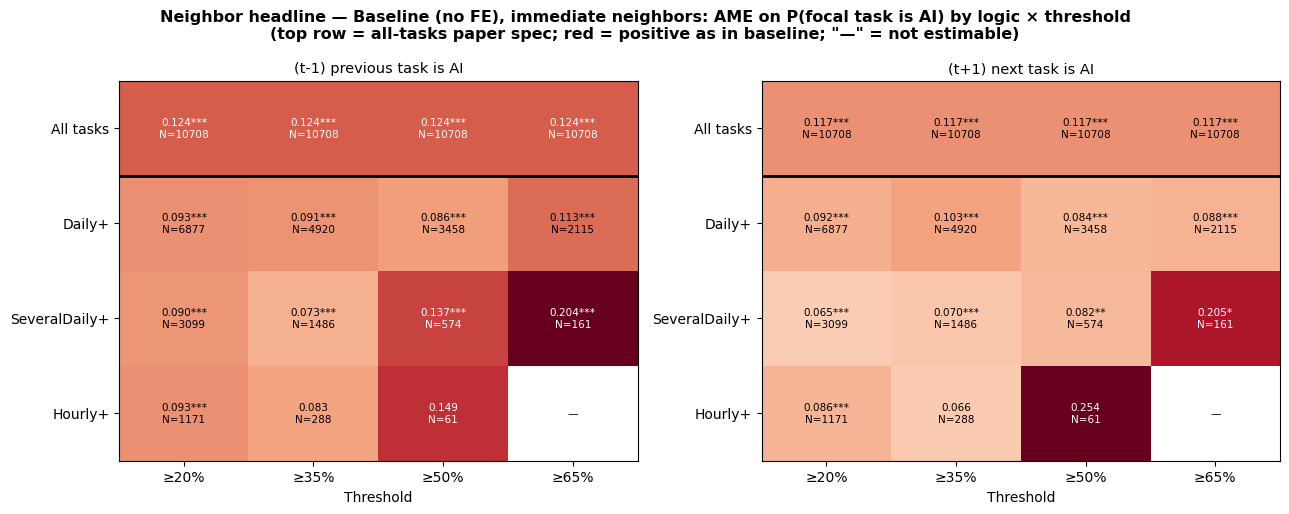

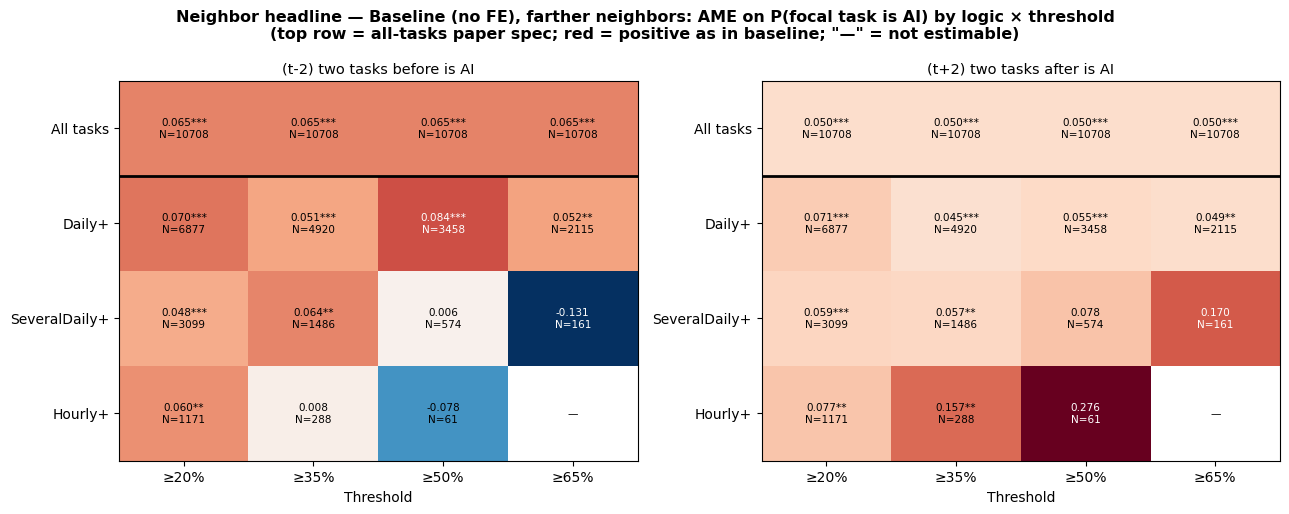

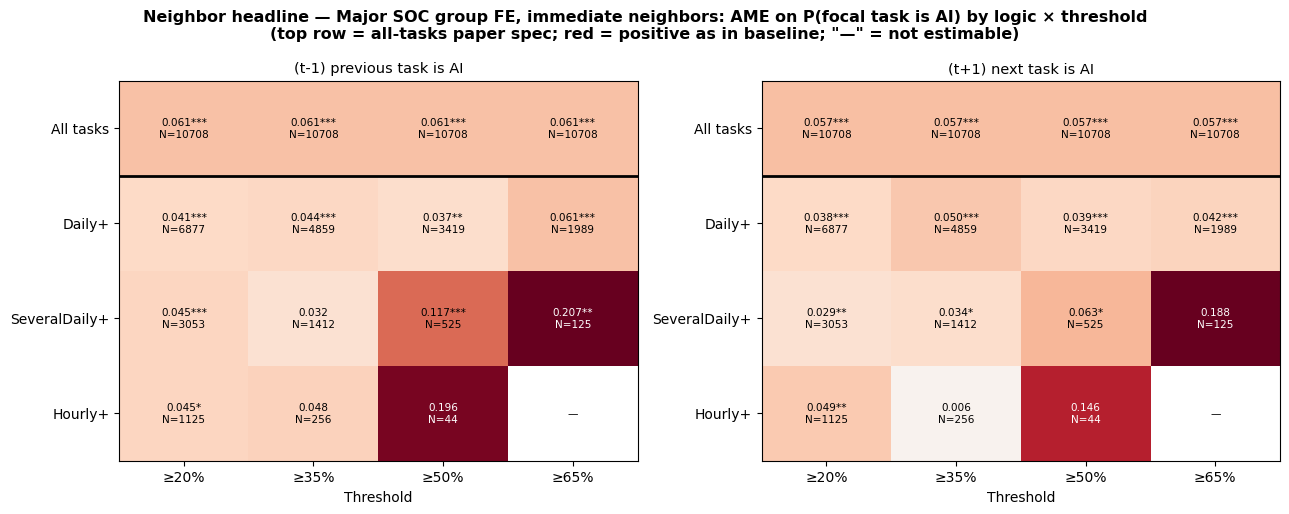

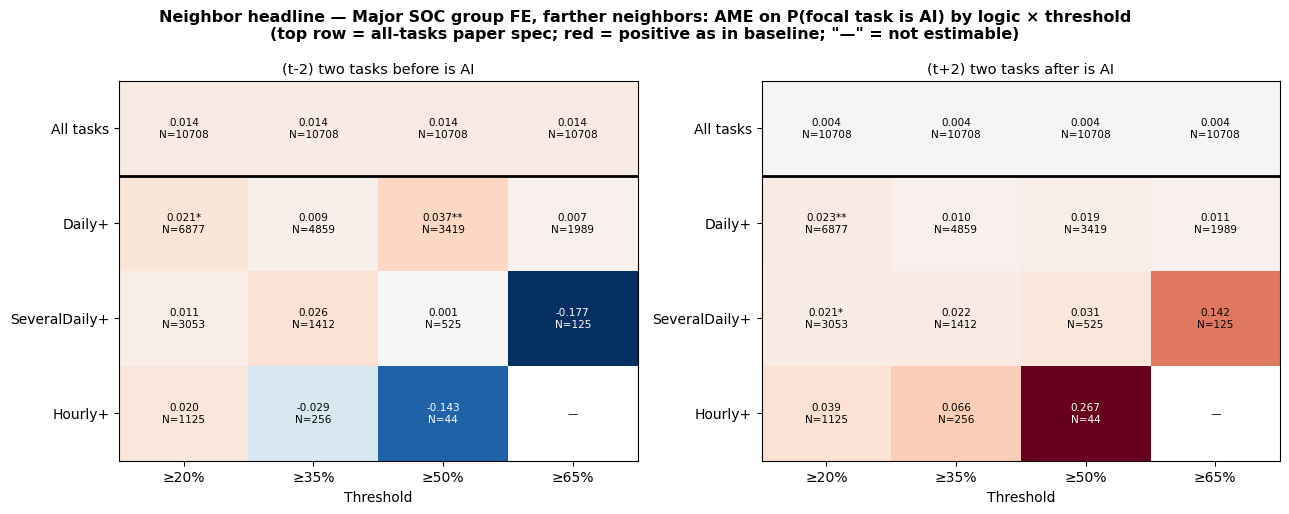

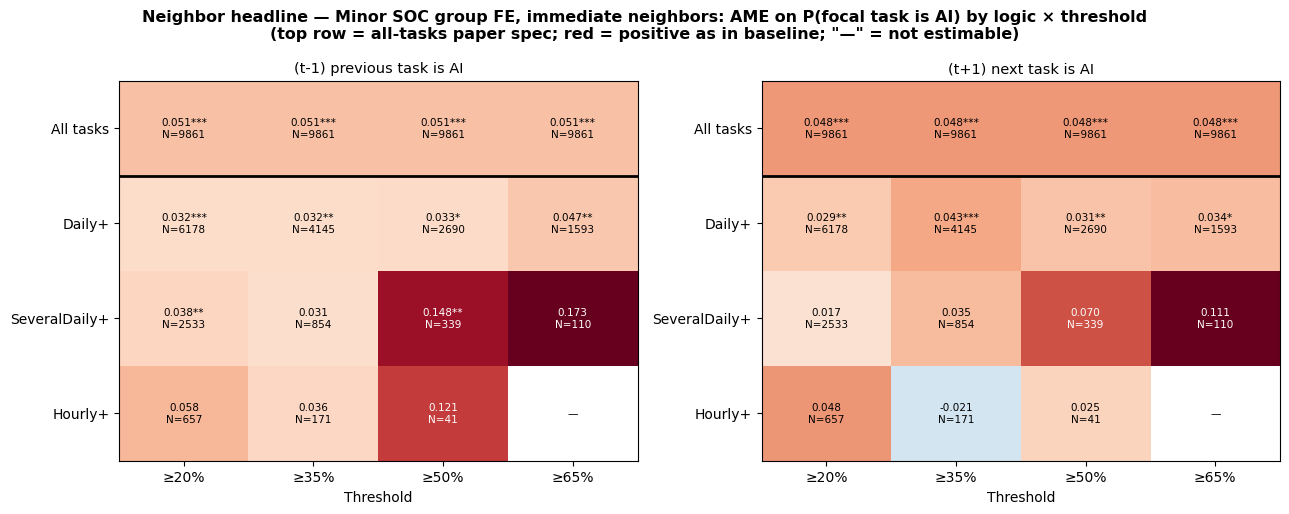

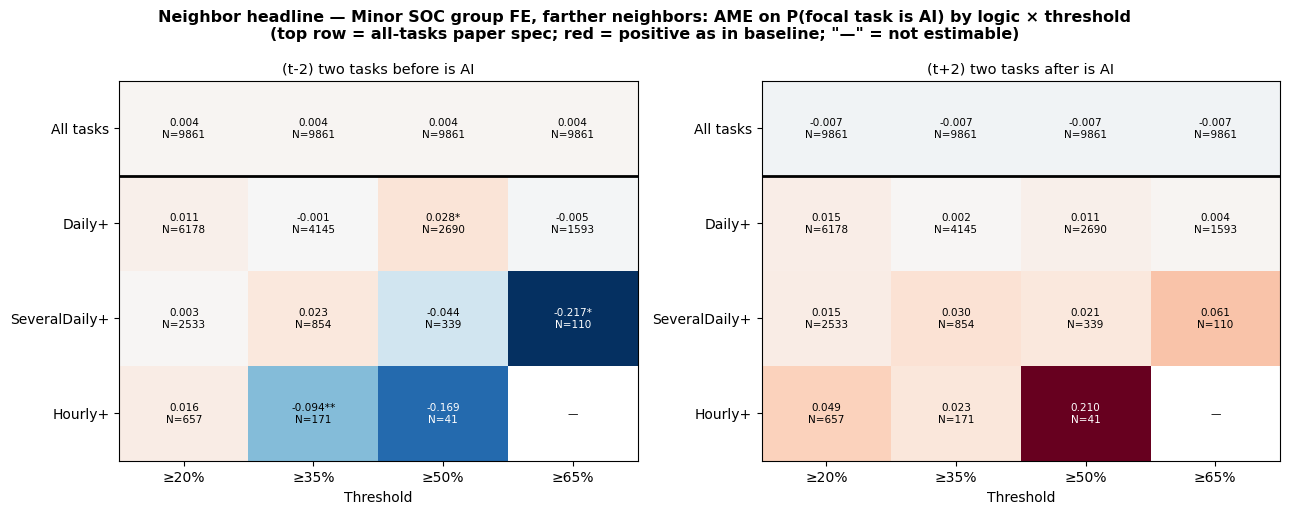

Saved 6 per-spec heatmap figures (immediate/farther x baseline/majorFE/minorFE) to ../writeup/plots/execTypeVaryingDWA_weeklyTasks


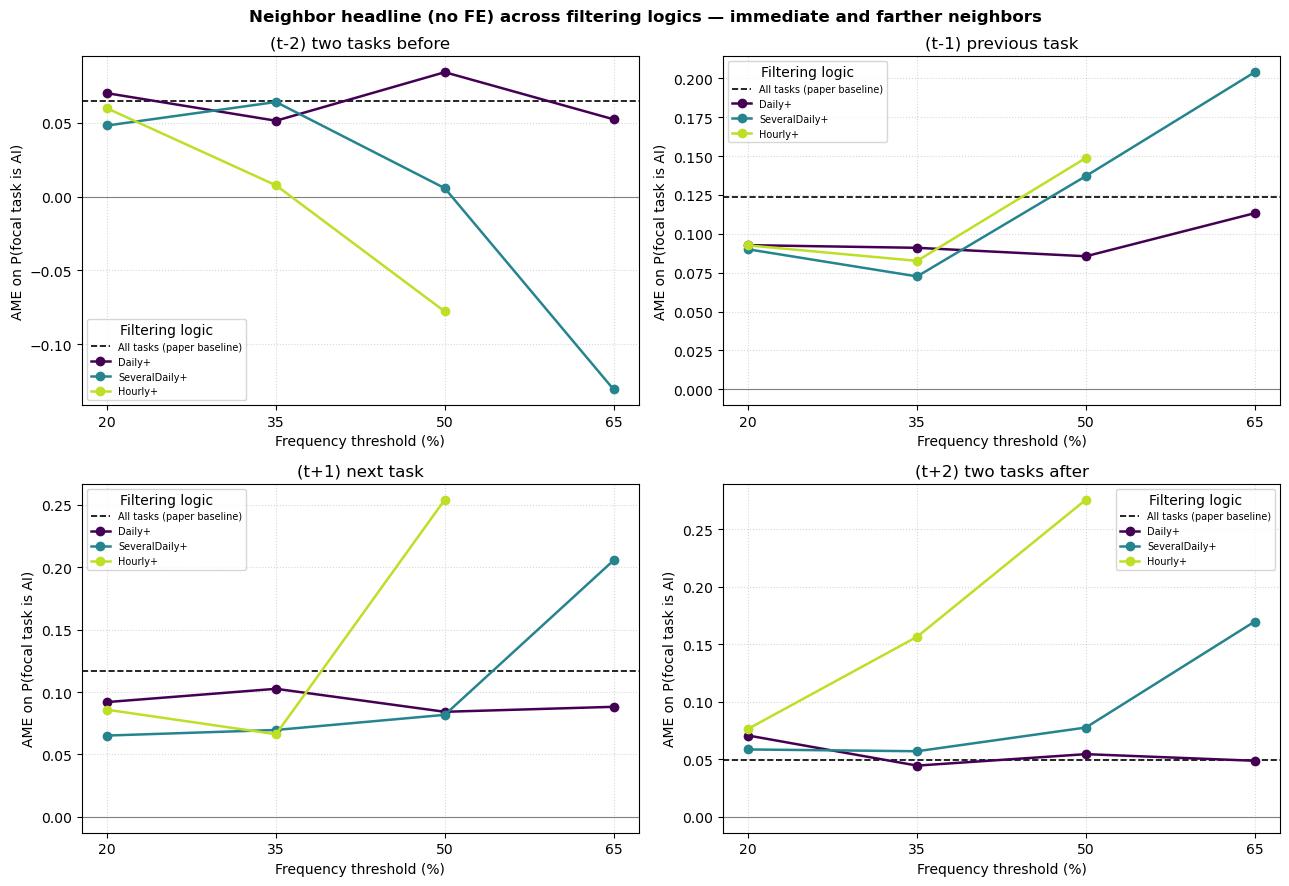

Saved heatmap + line figures to ../writeup/plots/execTypeVaryingDWA_weeklyTasks


In [12]:
from matplotlib.colors import TwoSlopeNorm
def heatmap(ax, spec, term, title):
    sub = sweep[(sweep['spec']==spec) & (sweep['term']==term)]
    M = np.full((len(row_order), len(SWEEP_THRESHOLDS)), np.nan)
    ann = [['—' for _ in SWEEP_THRESHOLDS] for _ in row_order]
    for i, fam in enumerate(row_order):
        for j, t in enumerate(SWEEP_THRESHOLDS):
            c = _cell(sub, fam, t)
            if c:
                M[i, j] = c[0]; ann[i][j] = f"{c[0]:.3f}{star(c[1])}\nN={c[2]}"
    vmax = np.nanmax(np.abs(M)) if np.isfinite(M).any() else 1.0
    ax.imshow(M, cmap='RdBu_r', norm=TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax), aspect='auto')
    ax.set_xticks(range(len(SWEEP_THRESHOLDS))); ax.set_xticklabels([f"≥{t}%" for t in SWEEP_THRESHOLDS])
    ax.set_yticks(range(len(row_order))); ax.set_yticklabels([row_label[f] for f in row_order])
    ax.axhline(0.5, color='black', lw=2)  # separate the paper's all-tasks baseline row
    for i in range(len(row_order)):
        for j in range(len(SWEEP_THRESHOLDS)):
            ax.text(j, i, ann[i][j], ha='center', va='center', fontsize=7.5,
                    color='black' if (np.isnan(M[i,j]) or abs(M[i,j])<0.6*vmax) else 'white')
    ax.set_title(title, fontsize=10.5); ax.set_xlabel('Threshold')

# Two heatmap figures per regression spec: immediate neighbors (t-1 left, t+1 right) and farther (t-2 left, t+2 right)
NB_FIG_GROUPS = [('immediate', 'immediate neighbors', ['prev_is_ai', 'next_is_ai']),
                 ('farther',   'farther neighbors',   ['prev2_is_ai', 'next2_is_ai'])]
for spec_code, spec_name, spec_tag in NB_SPECS:
    for group_tag, group_name, terms in NB_FIG_GROUPS:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
        for ax, term in zip(axes, terms):
            heatmap(ax, spec_code, term, TERM_TITLE[term] + ' is AI')
        fig.suptitle(f'Neighbor headline — {spec_name}, {group_name}: AME on P(focal task is AI) by logic × threshold\n(top row = all-tasks paper spec; red = positive as in baseline; "—" = not estimable)', fontweight='bold', fontsize=11.5)
        fig.tight_layout()
        fig.savefig(f"{output_plot_path}/neighbor_logic_threshold_heatmap_{group_tag}_{spec_tag}.png", dpi=200, bbox_inches='tight'); plt.show()
print("Saved 6 per-spec heatmap figures (immediate/farther x baseline/majorFE/minorFE) to", output_plot_path)

# Line view: 4 panels (one per neighbor position), one line per logic, baseline = dashed
fig2, axes2 = plt.subplots(2, 2, figsize=(13, 9))
cmap = plt.cm.viridis(np.linspace(0, 0.9, len(fam_order)))
for ax, term in zip(axes2.flat, TERMS_ORDER):
    sub = sweep[(sweep['spec']=='no_fe_no_dwa') & (sweep['term']==term)]
    base = sub[sub['family']=='all']['ame'].iloc[0]
    ax.axhline(base, color='black', ls='--', lw=1.2, label='All tasks (paper baseline)'); ax.axhline(0, color='gray', lw=0.8)
    for fam, c in zip(fam_order, cmap):
        s = sub[sub['family']==fam].sort_values('threshold')
        if len(s): ax.plot(s['threshold'], s['ame'], marker='o', color=c, lw=1.8, label=fam_label[fam])
    ax.set_title(TERM_TITLE[term]); ax.set_xlabel('Frequency threshold (%)'); ax.set_ylabel('AME on P(focal task is AI)')
    ax.set_xticks(SWEEP_THRESHOLDS); ax.grid(True, ls=':', alpha=0.5); ax.legend(fontsize=7, title='Filtering logic')
fig2.suptitle('Neighbor headline (no FE) across filtering logics — immediate and farther neighbors', fontweight='bold')
fig2.tight_layout(); fig2.savefig(f"{output_plot_path}/neighbor_logic_threshold_lines.png", dpi=200, bbox_inches='tight'); plt.show()
print("Saved heatmap + line figures to", output_plot_path)

## Takeaways

- **Step 1** — share of original-workflow tasks dropped under each cut.
- **Step 3** — the neighbor AMEs for baseline vs weekly+ >=50%, across all six specifications, for both the
  full-eligible and GPT-filtered samples. The headline survives if the immediate-neighbor (t-1, t+1) AMEs stay
  positive and significant (precision falls as the sample shrinks).
- **Step 4** — filtering-logic × threshold sweep across five logics (Monthly+/Weekly+/Daily+/SeveralDaily+/
  Hourly+) × four thresholds. For **each** regression spec (baseline / Major FE / Minor FE) there are two
  heatmap figures: `..._heatmap_immediate_{spec}.png` (t-1 left, t+1 right) and `..._heatmap_farther_{spec}.png`
  (t-2 left, t+2 right) — 6 figures total — plus no-FE line plots.
- Outputs in `data/computed_objects/execTypeVaryingDWA_anthropicIndex_weeklyTasks/`; figures in
  `writeup/plots/execTypeVaryingDWA_weeklyTasks/`.